<a href="https://colab.research.google.com/github/NDani23/CV_notebooks/blob/master/conv_segmentation.ipynb" 
target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Tho objective of this notebook is to create and train a fully convolution neural network for semantic segmentation.

## Installs



In [1]:
!pip3 install torch torchvision

## Check installs and CUDA

In [2]:
!nvcc --version
import torch
print(torch.cuda.is_available())

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
True


## Downloading database

In [3]:
!wget https://deeplearning.iit.bme.hu/Public/DL/RoboCupSeg.zip --no-check-certificate
!unzip -qq RoboCupSeg.zip
!rm RoboCupSeg.zip

--2025-11-08 13:00:21--  https://deeplearning.iit.bme.hu/Public/DL/RoboCupSeg.zip
Resolving deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)... 152.66.243.112
Connecting to deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)|152.66.243.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 39492484 (38M) [application/zip]
Saving to: ‘RoboCupSeg.zip’

RoboCupSeg.zip      100%[===================>]  37.66M  13.5MB/s    in 2.8s    

2025-11-08 13:00:24 (13.5 MB/s) - ‘RoboCupSeg.zip’ saved [39492484/39492484]



# Solution

## DataLoader

### Helper functions

In [4]:
import torch
import re

def tryint(s):
  try:
    return int(s)
  except:
    return s

def alphanum_key(s):
  """ Turn a string into a list of string and number chunks.
      "z23a" -> ["z", 23, "a"]
  """
  return [ tryint(c) for c in re.split('([0-9]+)', s) ]

class ToLabel(object):
  def __call__(self, tensor):
      return torch.squeeze(tensor.long())

### Random horizontal flip

In [5]:
from PIL import Image
import random

class HorizontalFlip(object):
  def __call__(self, img):
    if random.random() > 0.5:
      return img.transpose(Image.FLIP_LEFT_RIGHT)
    return img

### Loader

In [6]:
import torch
import numpy as np
import glob
import os.path as osp
from torch.utils import data

class SSDataSet(data.Dataset):
  def __init__(self, root, split="train", img_transform=None, label_transform = None):
    self.root = root
    self.plit = split
    self.img_transform = img_transform
    self.label_transform = label_transform

    data_dir = osp.join(root, split)
    self.img_dir = osp.join(data_dir, "images")
    self.lab_dir = osp.join(data_dir, "labels")

    self.images = sorted(glob.glob1(self.img_dir, "*.jpg"), key=alphanum_key)
    self.labels = sorted(glob.glob1(self.lab_dir, "*.png"), key=alphanum_key)

  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
    img_file=osp.join(self.img_dir, self.images[index])
    lab_file=osp.join(self.lab_dir, self.labels[index])

    img = Image.open(img_file).convert('RGB')
    label = Image.open(lab_file).convert('I')

    seed = np.random.randint(9999999999)

    random.seed(seed)
    if self.img_transform is not None:
      img = self.img_transform(img)

    random.seed(seed)
    if self.label_transform is not None:
      label = self.label_transform(label)

    return img, label


## Creating the model

### Conv layer

In [7]:
import torch
import torch.nn as nn

class Conv(nn.Module):
  def __init__(self, inplanes, planes, size=3, stride=1):
    super(Conv, self).__init__()
    self.conv = nn.Conv2d(inplanes, planes, kernel_size=size, padding=size // 2, stride=stride)
    self.bn = nn.BatchNorm2d(planes)

  def forward(self, x):
    return self.bn(torch.relu(self.conv(x)))

### Transpose Conv

In [15]:
class TrConv(nn.Module):
  def __init__(self, inplanes, planes, size=3, stride=2):
    super(TrConv, self).__init__()
    self.trConv = nn.ConvTranspose2d(inplanes, planes, kernel_size=size, padding = size // 2, stride=stride, output_padding=1)
    self.bn = nn.BatchNorm2d(planes)

  def forward(self, x):
    return self.bn(torch.relu(self.trConv(x)))

### Modell

In [28]:
class FCN(nn.Module):
  def __init__(self, planes, numClass = 5):
    super().__init__()

    self.c1 = Conv(3, planes)
    self.d1 = Conv(planes, planes * 2, stride=2)
    self.c2 = Conv(planes * 2, planes * 2)
    self.d2 = Conv(planes * 2, planes * 4, stride = 2) # downscaling with strided convolution
    self.c3 = Conv(planes * 4, planes * 4)
    self.d3 = Conv(planes * 4, planes * 8, stride = 2)
    self.c4 = Conv(planes * 8, planes * 8)
    self.d4 = Conv(planes * 8, planes * 16, stride = 2)
    self.c5 = Conv(planes * 16, planes * 16)

    self.u1 = TrConv(planes * 16, planes * 8) # transpose convolution for upscaling
    self.u2 = TrConv(planes * 8, planes * 4)
    self.u3 = TrConv(planes * 4, planes * 2)
    self.u4 = TrConv(planes * 2, planes)

    self.classifier = nn.Conv2d(planes, numClass, kernel_size=5, padding=2)

  def forward(self, x):
    l1 = self.c1(x)
    l2 = self.c2(self.d1(l1))
    l3 = self.c3(self.d2(l2))
    l4 = self.c4(self.d3(l3))
    l5 = self.c5(self.d4(l4))

    u4 = self.u1(l5) + l4
    u3 = self.u2(u4) + l3
    u2 = self.u3(u3) + l2
    u1 = self.u4(u2) + l1

    return self.classifier(u1)

## Train function

In [29]:
from IPython.display import HTML, display

# progress bar for training
def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

def train(epoch):

  # variables for loss
  running_loss = 0.0
  correct = 0.0
  total = 0

  # set the network to train (for batchnorm and dropout)
  net.train()

  # Create progress bar
  bar = display(progress(0, len(trainLoader)), display_id=True)

  # Epoch loop
  for i, data in enumerate(trainLoader, 0):
    # get the inputs
    inputs, labels = data

    # Convert to cuda conditionally
    inputs, labels = inputs.cuda(), labels.cuda()


    # zero the parameter gradients
    optimizer.zero_grad()

    # forward + backward + optimize
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # compute statistics
    running_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += torch.sum(predicted.data == labels.data).item()/(160*128)*100

    # Update progress bar
    bar.update(progress(i+1, len(trainLoader)))

  # print and plot statistics
  tr_loss = running_loss / len(trainLoader)
  tr_corr = correct / total
  print("Epoch [%d] Training Loss: %.4f Training Pixel Acc: %.2f" % (epoch+1, tr_loss, tr_corr))

  return tr_loss,tr_corr

## Val function

In [30]:
def val(epoch):

  # variables for loss
  running_loss = 0.0
  correct = 0.0
  total = 0

  # IoU computation
  conf = torch.zeros(numClass,numClass)
  IoU = torch.zeros(numClass)
  labCnts = torch.zeros(numClass)

  # set the network to eval (for batchnorm and dropout)
  net.eval()

  # Create progress bar
  bar = display(progress(0, len(testLoader)), display_id=True)

  # Epoch loop
  for i, data in enumerate(testLoader, 0):
    # get the inputs
    inputs, labels = data

    # Convert to cuda conditionally
    inputs, labels = inputs.cuda(), labels.cuda()

    # forward
    outputs = net(inputs)
    loss = criterion(outputs, labels)

    # compute statistics
    running_loss += loss.item()
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += torch.sum( predicted.data == labels.data ).item()/(160*128)*100

    bSize = labels.size(0)
    labSize = labels.size()[1:3]
    H, W = labSize

    # Compute mIoU (mean intersection over union)
    maskPred = torch.zeros(numClass, bSize, H, W).long()
    maskTarget = torch.zeros(numClass, bSize, H, W).long()
    for currClass in range(numClass):
      maskPred[currClass] = (predicted == currClass)
      maskTarget[currClass] = (labels == currClass)

    for imgInd in range(bSize):
      for labIdx in range(numClass):
        labCnts[labIdx] += maskTarget[labIdx, imgInd].sum().item()

        for predIdx in range(numClass):
          inter = (maskTarget[labIdx, imgInd] & maskPred[predIdx, imgInd]).sum().item()

          #confusion matrix
          conf[(predIdx,labIdx)] += inter

          if labIdx == predIdx:
            union = (maskTarget[labIdx, imgInd] | maskPred[predIdx, imgInd]).sum().item()
            IoU[labIdx] += inter/union if union else 1
    # Update progress bar
    bar.update(progress(i+1, len(testLoader)))

  # print and plot statistics
  for labIdx in range(numClass):
    for predIdx in range(numClass):
      conf[(predIdx, labIdx)] /= (labCnts[labIdx] / 100.0)
  meanClassAcc = 0.0
  meanIoU = torch.sum(IoU/total).item() / numClass * 100
  currLoss = running_loss/(i+1)
  for j in range(numClass):
    meanClassAcc += conf[(j,j)]/numClass
  print("Epoch [%d] Validation Loss: %.4f Validation Pixel Acc: %.2f Mean Class Acc: %.2f IoU: %.2f" %
        (epoch+1, running_loss/(i+1), correct/(total), meanClassAcc, meanIoU))

  return currLoss, correct/(total)

## Training

### preparing training data

In [31]:
import torchvision
import torchvision.transforms as transforms
from PIL import Image

numClass = 5

input_transform = transforms.Compose(
    [
        transforms.Resize((128, 160), Image.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5, 0.5, 0.5],
            [0.25, 0.25, 0.25]
        )

    ]
)
input_transform_tr = transforms.Compose(
    [
        transforms.Resize((128, 160), Image.BILINEAR),
        HorizontalFlip(),
        transforms.ColorJitter(0.3, 0.3, 0.2, 0.15),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5, 0.5, 0.5],
            [0.25, 0.25, 0.25]
        )
    ]
)
target_transform = transforms.Compose(
    [
        transforms.Resize((128, 160), Image.NEAREST),
        transforms.ToTensor(),
        ToLabel()
    ]
)
target_transform_tr = transforms.Compose(
    [
        transforms.Resize((128, 160), Image.NEAREST),
        HorizontalFlip(),
        transforms.ToTensor(),
        ToLabel()
    ]
)


trainLoader = data.DataLoader(SSDataSet("RoboCupSeg", split="train", img_transform=input_transform_tr,
                                             label_transform=target_transform_tr),
                                  batch_size=8, shuffle=True)

testLoader = data.DataLoader(SSDataSet("RoboCupSeg", split="val", img_transform=input_transform,
                                             label_transform=target_transform),
                                  batch_size=8, shuffle=True)

### Train the model

Epoch [1] Training Loss: 0.9557 Training Pixel Acc: 79.98


Epoch [1] Validation Loss: 0.8963 Validation Pixel Acc: 81.07 Mean Class Acc: 37.68 IoU: 25.48


Epoch [2] Training Loss: 0.3798 Training Pixel Acc: 91.22


Epoch [2] Validation Loss: 0.2461 Validation Pixel Acc: 93.21 Mean Class Acc: 43.89 IoU: 36.41


Epoch [3] Training Loss: 0.2475 Training Pixel Acc: 92.76


...

Epoch [28] Validation Loss: 0.0466 Validation Pixel Acc: 98.30 Mean Class Acc: 90.47 IoU: 76.50


Epoch [29] Training Loss: 0.0449 Training Pixel Acc: 98.38


Epoch [29] Validation Loss: 0.0449 Validation Pixel Acc: 98.32 Mean Class Acc: 90.76 IoU: 77.39


Epoch [30] Training Loss: 0.0449 Training Pixel Acc: 98.36


Epoch [30] Validation Loss: 0.0485 Validation Pixel Acc: 98.32 Mean Class Acc: 90.57 IoU: 77.18
Finished Training


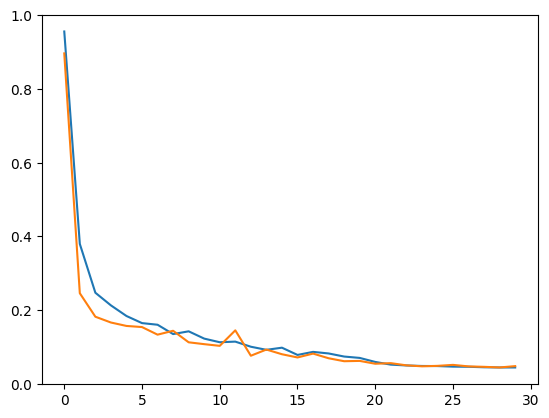

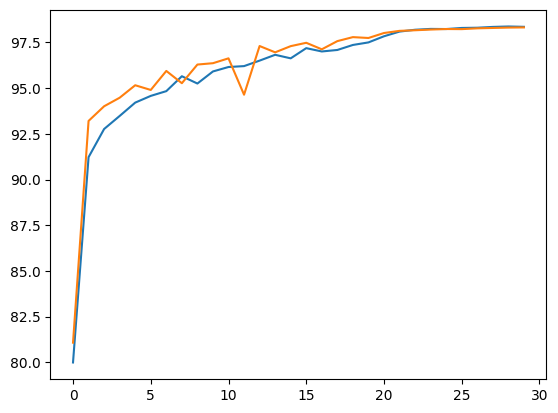

In [32]:
import torch.optim as optim
from torch.optim import lr_scheduler

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Makes multiple runs comparable
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

net = FCN(16,numClass).cuda()

criterion = nn.CrossEntropyLoss().cuda()

optimizer = optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = lr_scheduler.StepLR(optimizer,20)

# Epoch counter
numEpoch = 30

trLosses = []
trAccs = []
valLosses = []
valAccs = []

for epoch in range(numEpoch):

  # Call train and val
  tr_loss,tr_corr = train(epoch)
  val_loss,val_corr = val(epoch)

  trLosses.append(tr_loss)
  trAccs.append(tr_corr)
  valLosses.append(val_loss)
  valAccs.append(val_corr)

  # Step with the scheduler
  scheduler.step()

# Finished
print('Finished Training')
plt.plot(trLosses)
plt.plot(valLosses)
plt.show()
plt.plot(trAccs)
plt.plot(valAccs)
plt.show()


# Visualization

In [33]:
def Colorize(gray_image):
  cmap = torch.ByteTensor([
                           [0,0,0],
                           [255,0,0],
                           [0,255,0],
                           [0,0,255],
                           [255,255,255]
  ])
  size = gray_image.shape
  color_image = torch.ByteTensor(3, size[0], size[1]).fill_(0)

  for label in range(len(cmap)):
    mask = (gray_image == label).cpu()
    color_image[0][mask] = cmap[label][0]
    color_image[1][mask] = cmap[label][1]
    color_image[2][mask] = cmap[label][2]

  return color_image

### A mini-batch

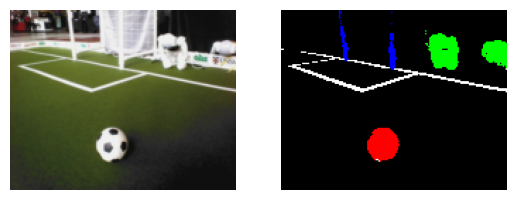

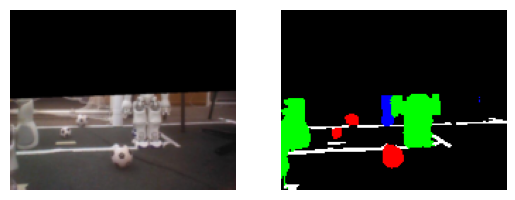

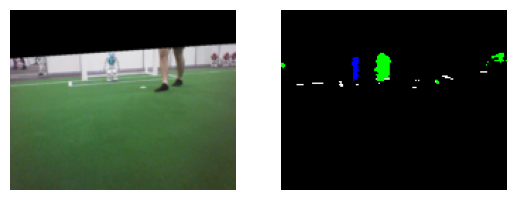

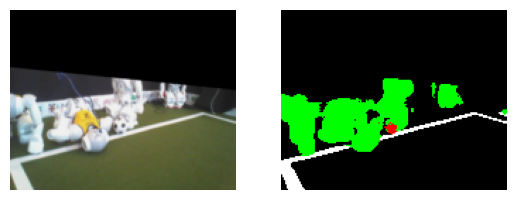

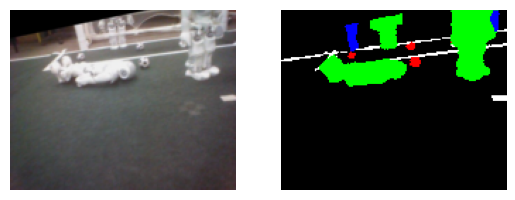

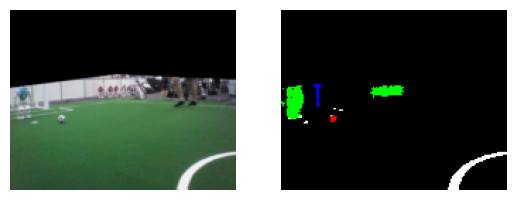

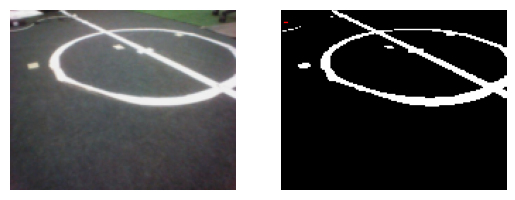

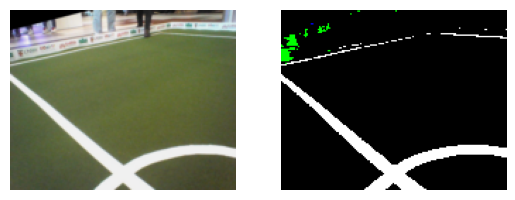

In [38]:
%matplotlib inline
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

for i, (images, labels) in enumerate(testLoader):
    images = images.cuda()
    pred = net(images)
    _, predClass = torch.max(pred, 1)
    bSize = images.size(0)
    for j in range(bSize):
        label = Image.fromarray(Colorize(predClass[j]).permute(1, 2, 0).numpy().astype('uint8'))
        img = Image.fromarray(((images[j].permute(1, 2, 0).cpu().numpy()/4 + 0.5)*240).astype('uint8'))
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.axis('off')
        imshow(img)
        plt.subplot(1, 2, 2)
        plt.axis('off')
        imshow(label)
    plt.show()
    break